# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting. 

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points) 
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries? 

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below: 

* Source 1: https://en.wikipedia.org/wiki/Gaussian_blur
This article explains the math behind Gaussian blur, including how the kernel is constructed using the Gaussian function. It covers both the 1D and 2D cases and explains how sigma controls the spread of the blur. 
* Source 2: https://computergraphics.stackexchange.com/questions/39/how-is-gaussian-blur-implemented This post discusses how Gaussian blur is implemented in practice, including the convolution approach used to apply the kernel to an image. It also explains the separability property of the Gaussian kernel.
* Source 3: https://stackoverflow.com/questions/1696113/how-do-i-gaussian-blur-an-image-without-using-any-in-built-gaussian-functions This thread walks through how to implement Gaussian blur from scratch without using built-in functions. It was helpful for understanding how to manually construct the kernel and apply it pixel by pixel using convolution.
* Source 4: https://en.wikipedia.org/wiki/Vignetting This article describes vignetting as the reduction of brightness toward the edges of an image. The effect is intentionally recreated to draw the viewer's eye toward the center of the image. 
* Source 5: https://stackoverflow.com/questions/23007064/effect-of-variance-sigma-at-gaussian-smoothing To deepen my understanding in preparation for implementing my blue factor, I read this article that explains how sigma controls the strength of the blur. A larger sigma spreads the kernel wider, giving more weight to farther neighbors and producing a blurrier result. 
* Source 6: https://stackoverflow.com/questions/25701196/combining-two-images-multiplying-rgb-values-to-vignette-an-image-jython-python This post demonstrates how to blend two images together using a mask to create a vignette effect in Python. It was useful for understanding how to combine the original and blurred image based on pixel distance from the center.

## Code (70 points) 
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient. 

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


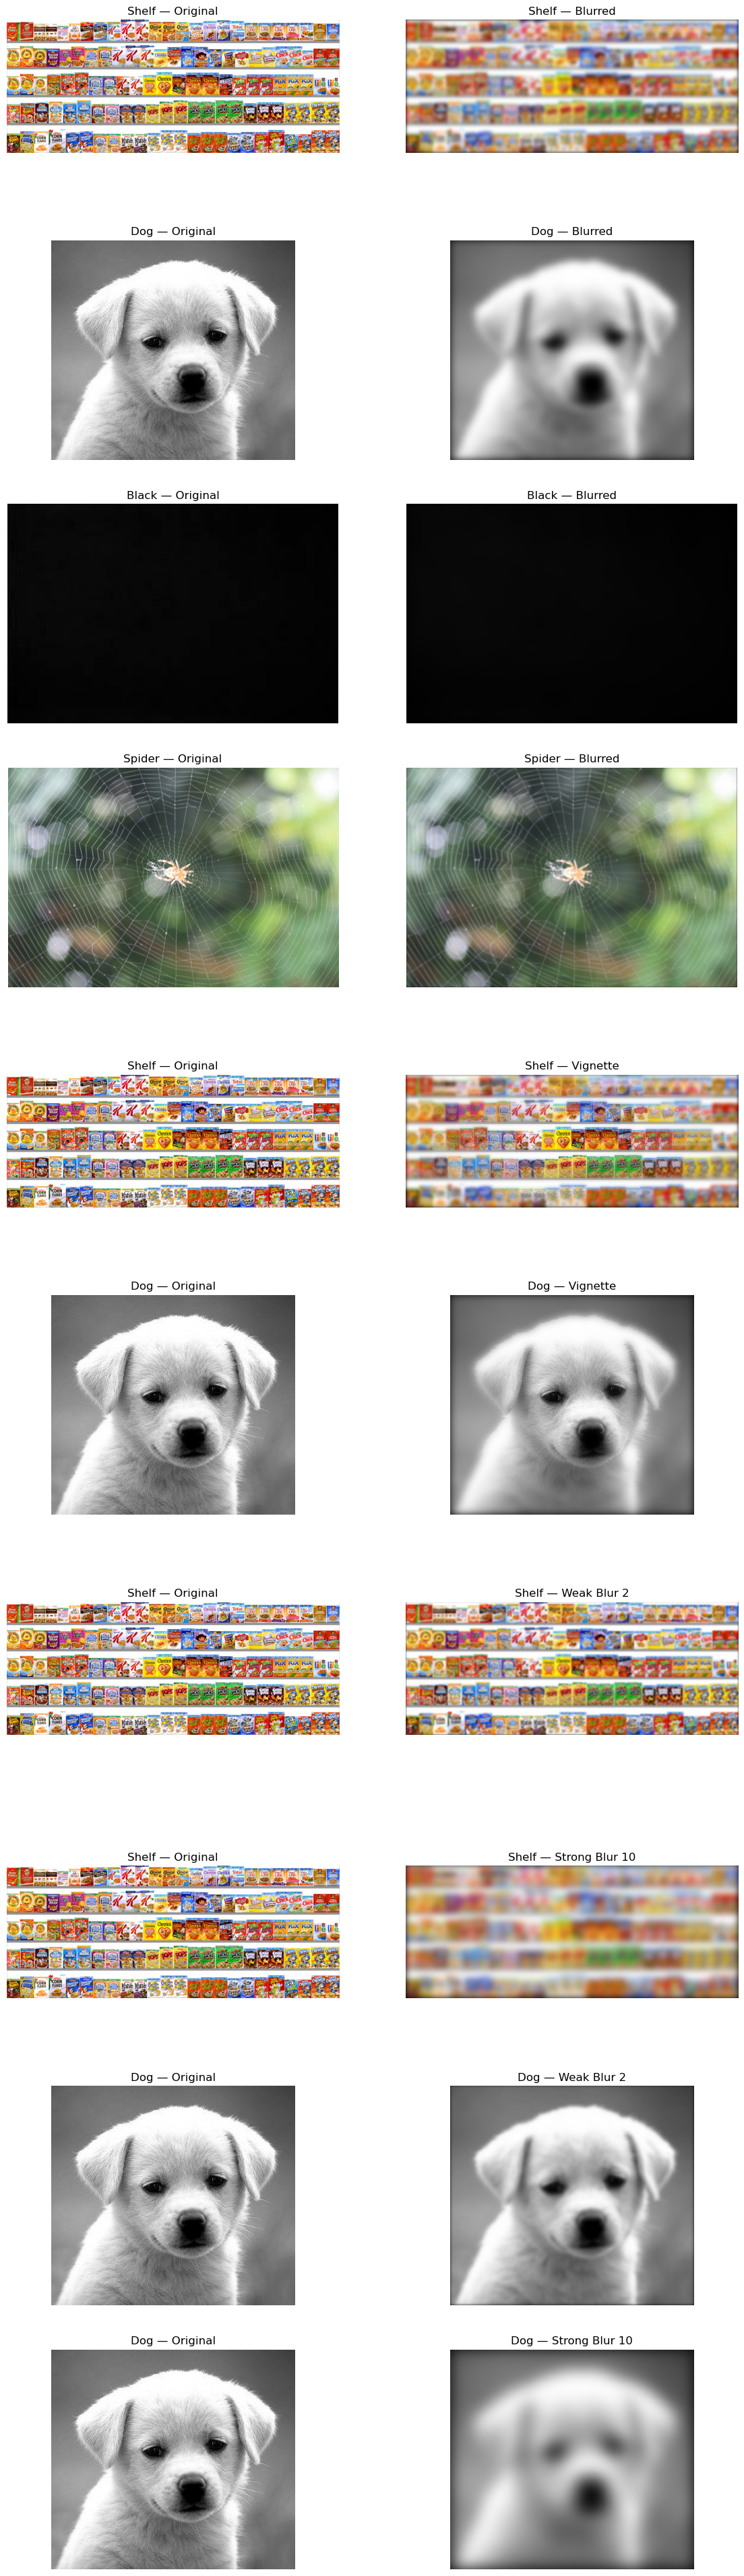

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from filters import conv_fast

BLUR_FACTOR = 5
BLUR_FACTOR_WEAK = 2
BLUR_FACTOR_STRONG = 10

def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return G / G.sum()

def blur_image(img_array, blur_factor=1.0):
    sigma = blur_factor

    size = max(3, int(6 * sigma) | 1)

    kernel = gaussian_kernel(size=size, sigma=sigma)

    if img_array.ndim == 3:
        channels = []
        for c in range(img_array.shape[2]):
            channel = img_array[:, :, c]
            blurred_channel = conv_fast(channel, kernel)
            channels.append(blurred_channel)

        blurred = np.stack(channels, axis=2)
    else:
        blurred = conv_fast(img_array, kernel)

    blurred = np.clip(blurred, 0, 255)
    blurred = blurred.astype(np.uint8)

    return blurred

def add_vignette(img_array, blur_factor=5.0):
    h = img_array.shape[0]
    w = img_array.shape[1]
    y, x = np.mgrid[0:h, 0:w]

    cy = h / 2
    cx = w / 2

    x_norm = (x - cx) / cx
    y_norm = (y - cy) / cy

    dist = np.sqrt(x_norm ** 2 + y_norm ** 2)
    dist_clipped = np.clip(dist, 0, 1)
    mask = 1 - dist_clipped
    mask = mask[:, :, np.newaxis]

    blurred = blur_image(img_array, blur_factor=blur_factor)

    result = (mask * img_array) + ((1 - mask) * blurred)
    result = np.clip(result, 0, 255)
    result = result.astype(np.uint8)

    return result

shelf = np.array(Image.open("shelf.jpg"))
dog = np.array(Image.open("dog.jpg"))
black = np.array(Image.open("black.jpg"))
spider = np.array(Image.open("spider.jpg"))

shelf_blurred = blur_image(shelf, blur_factor=BLUR_FACTOR)
dog_blurred = blur_image(dog, blur_factor=BLUR_FACTOR)
black_blurred = blur_image(black, blur_factor=BLUR_FACTOR)
spider_blurred = blur_image(spider, blur_factor=BLUR_FACTOR)
shelf_vignette = add_vignette(shelf, blur_factor=BLUR_FACTOR)
dog_vignette = add_vignette(dog, blur_factor=BLUR_FACTOR)
shelf_weak = blur_image(shelf, blur_factor=BLUR_FACTOR_WEAK)
shelf_strong = blur_image(shelf, blur_factor=BLUR_FACTOR_STRONG)
dog_weak = blur_image(dog, blur_factor=BLUR_FACTOR_WEAK)
dog_strong = blur_image(dog, blur_factor=BLUR_FACTOR_STRONG)

plt.figure(figsize=(14, 50))

plt.subplot(10, 2, 1)
plt.imshow(shelf)
plt.title('Shelf — Original')
plt.axis('off')

plt.subplot(10, 2, 2)
plt.imshow(shelf_blurred)
plt.title('Shelf — Blurred')
plt.axis('off')

plt.subplot(10, 2, 3)
plt.imshow(dog)
plt.title('Dog — Original')
plt.axis('off')

plt.subplot(10, 2, 4)
plt.imshow(dog_blurred)
plt.title('Dog — Blurred')
plt.axis('off')

plt.subplot(10, 2, 5)
plt.imshow(black)
plt.title('Black — Original')
plt.axis('off')

plt.subplot(10, 2, 6)
plt.imshow(black_blurred)
plt.title('Black — Blurred')
plt.axis('off')

plt.subplot(10, 2, 7)
plt.imshow(spider)
plt.title('Spider — Original')
plt.axis('off')

plt.subplot(10, 2, 8)
plt.imshow(spider_blurred)
plt.title('Spider — Blurred')
plt.axis('off')

plt.subplot(10, 2, 9)
plt.imshow(shelf)
plt.title('Shelf — Original')
plt.axis('off')

plt.subplot(10, 2, 10)
plt.imshow(shelf_vignette)
plt.title('Shelf — Vignette')
plt.axis('off')

plt.subplot(10, 2, 11)
plt.imshow(dog)
plt.title('Dog — Original')
plt.axis('off')

plt.subplot(10, 2, 12)
plt.imshow(dog_vignette)
plt.title('Dog — Vignette')
plt.axis('off')

plt.subplot(10, 2, 13)
plt.imshow(shelf)
plt.title('Shelf — Original')
plt.axis('off')

plt.subplot(10, 2, 14)
plt.imshow(shelf_weak)
plt.title(f'Shelf — Weak Blur 2')
plt.axis('off')

plt.subplot(10, 2, 15)
plt.imshow(shelf)
plt.title('Shelf — Original')
plt.axis('off')

plt.subplot(10, 2, 16)
plt.imshow(shelf_strong)
plt.title(f'Shelf — Strong Blur 10')
plt.axis('off')

plt.subplot(10, 2, 17)
plt.imshow(dog)
plt.title('Dog — Original')
plt.axis('off')

plt.subplot(10, 2, 18)
plt.imshow(dog_weak)
plt.title(f'Dog — Weak Blur 2')
plt.axis('off')

plt.subplot(10, 2, 19)
plt.imshow(dog)
plt.title('Dog — Original')
plt.axis('off')

plt.subplot(10, 2, 20)
plt.imshow(dog_strong)
plt.title(f'Dog — Strong Blur 10')
plt.axis('off')

plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

I built on top of the conv_fast function from Part 1 and implemented an adjustable Gaussian blur filter, using a 2D Gaussian kernel using the formulas found on Wikipedia and Stack exchange. To achieve this, I write three functions: gaussian_kernel, blur_image, and add_vignette.

After creating an initial blur, I wanted to enhance this by being able to tune the blur factor and using this to create a vignette. 

The gaussian_kernel function creates a grid of numbers where values are highest at the center and decrease outward, following the shape of a bell curve. It then scales all the values so they add up to 1, keeping the image the same brightness after blurring. The blur_image filter blurs an image by applying the Gaussian kernel, replacing each pixel with a weighted average of its neighbors. The stronger the blur factor, the wider the kernel and the more blurred the result. The add_vignette function measures how far each pixel is from the center of the image and uses that to blend between the original and the blurred version. Pixels near the center stay clear while pixels near the edges become increasingly blurred.

Displayed in the figure above, the filter works well for images with a great amount of detail. For example, the shelf and dog images differ heavily from their blurred versions. However, for plain color images (black) there is no effect because there is simply nothing to blur. Additionally for the spider image, there is no effect. The original spider image is slightly out of focus, creating an inherent blur. This in combination with the fine details of the image make the blur effect useless. I compare the shelf and dog images for 3 blur factors: 2, 5, 10. At 10, we lose the most detail. 

I did some research into other types of filters I'd like to experiment with if I continued working on this, such as the bilaterial filter or lens blur for out of focus images like the spider. Since the Gaussian uniformly blurs, these other filters would be interesting to experiment with because they blur by similar color. 

(All images attached to my code above)